##### Code added to rename the data sheet columns

In [66]:
import pandas as pd

raw_df         = pd.read_csv("master_data_fy.csv")
current_cols   = raw_df.columns.to_list()
variables      = ['firm_size', 'total_br', 'bank_br']
years          = list(range(2005,2025))
new_cols       = current_cols[0:2] + [f"{vars}_{yr}" for yr in years for vars in variables]
raw_df.columns = new_cols
raw_df.to_csv("renamed_master_nic_data.csv")


/Users/shivam/uv_venvs/da/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/shivam/uv_venvs/da/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


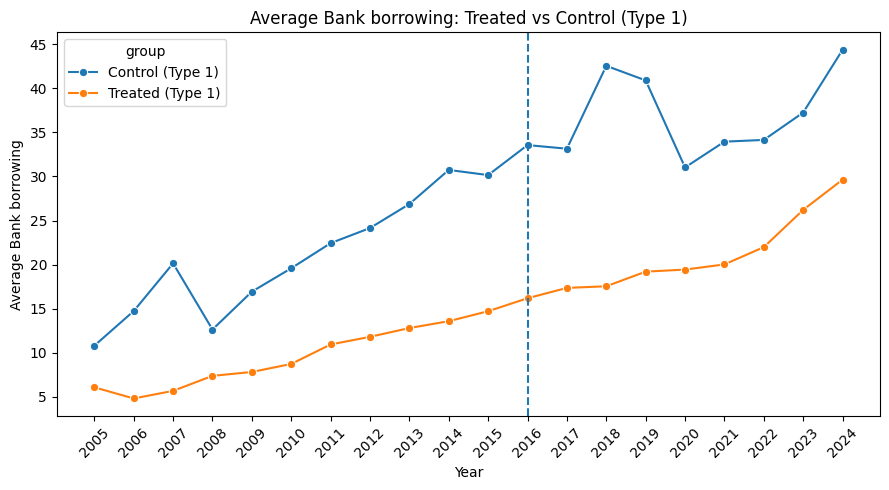

In [80]:
import pandas as pd
import numpy as np

df = pd.read_csv("renamed_master_nic_data.csv")
ID_COL = "Company Name"

df["2D_NIC"] = df["NIC code"].apply(lambda x: int(str(x)[:2]) if len(str(x)) >= 2 else x)

# --------------------------
# Type 1: ONLY 2015 size
# --------------------------
size_2015 = df["firm_size_2015"]

treated_type1 = size_2015.between(6, 10, inclusive="left") & size_2015.notna()   # [6,10)
control_type1 = size_2015.between(10, 14, inclusive="left") & size_2015.notna()  # [10,14)

df["treated_type1"] = treated_type1.astype(int)
df["control_type1"] = control_type1.astype(int)

# Reshape to long format
panel = (
    pd.wide_to_long(
        df,
        stubnames=["firm_size", "total_br", "bank_br"],
        i=ID_COL,
        j="year",
        sep="_",
        suffix=r"\d{4}"
    )
    .reset_index()
)

# numeric conversion
num_cols = ["firm_size", "total_br", "bank_br"]
panel[num_cols] = panel[num_cols].apply(pd.to_numeric, errors="coerce")

panel["year"] = panel["year"].astype(int)
panel = panel.sort_values([ID_COL, "year"]).reset_index(drop=True)

# keep only treated + control firms
panel = panel[(panel["treated_type1"] == 1) | (panel["control_type1"] == 1)].copy()

# DiD time dummies
panel["post"] = (panel["year"] > 2015).astype(int)
panel["did"]  = panel["treated_type1"] * panel["post"]

# outcome transform
panel["log_bank_br"] = np.log1p(panel["bank_br"])
panel["log_total_br"] = np.log(panel["total_br"])

# keep rows used in regressions/plots
panel = panel.dropna(subset=["bank_br", "log_bank_br"]).copy()

import seaborn as sns
import matplotlib.pyplot as plt

borrow_choice = input(
    "Choose borrowing type to plot:\n"
    "1 = Bank borrowing\n"
    "2 = Total borrowing\n"
    "Enter 1 or 2: "
).strip()

borrow_map = {"1": "bank_br", "2": "total_br"}
if borrow_choice not in borrow_map:
    raise ValueError("Invalid choice. Enter 1 or 2.")
yvar = borrow_map[borrow_choice]

how = input("Choose aggregation type ('mean' or 'sum'): ").strip().lower()
if how not in ["mean", "sum"]:
    raise ValueError("Invalid input. Enter 'mean' or 'sum'.")

borrow_label_map = {
    "bank_br": "Bank borrowing",
    "total_br": "Total borrowing"
}

plot_df = panel.copy()
plot_df["group"] = np.where(plot_df["treated_type1"] == 1, "Treated (Type 1)", "Control (Type 1)")

if how == "mean":
    plot_df = plot_df.groupby(["year", "group"], as_index=False)[yvar].mean()
else:
    plot_df = plot_df.groupby(["year", "group"], as_index=False)[yvar].sum()

plt.figure(figsize=(9, 5))
sns.lineplot(data=plot_df, x="year", y=yvar, hue="group", marker="o", errorbar=None)
plt.axvline(2016, linestyle="--", linewidth=1.5)
plt.xlabel("Year")

ylabel = f"Average {borrow_label_map[yvar]}" if how == "mean" else f"Total {borrow_label_map[yvar]}"
plt.ylabel(ylabel)
plt.title(f"{ylabel}: Treated vs Control (Type 1)")
plt.xticks(sorted(plot_df["year"].unique()), rotation=45)
plt.tight_layout()
plt.show()

/Users/shivam/uv_venvs/da/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/shivam/uv_venvs/da/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


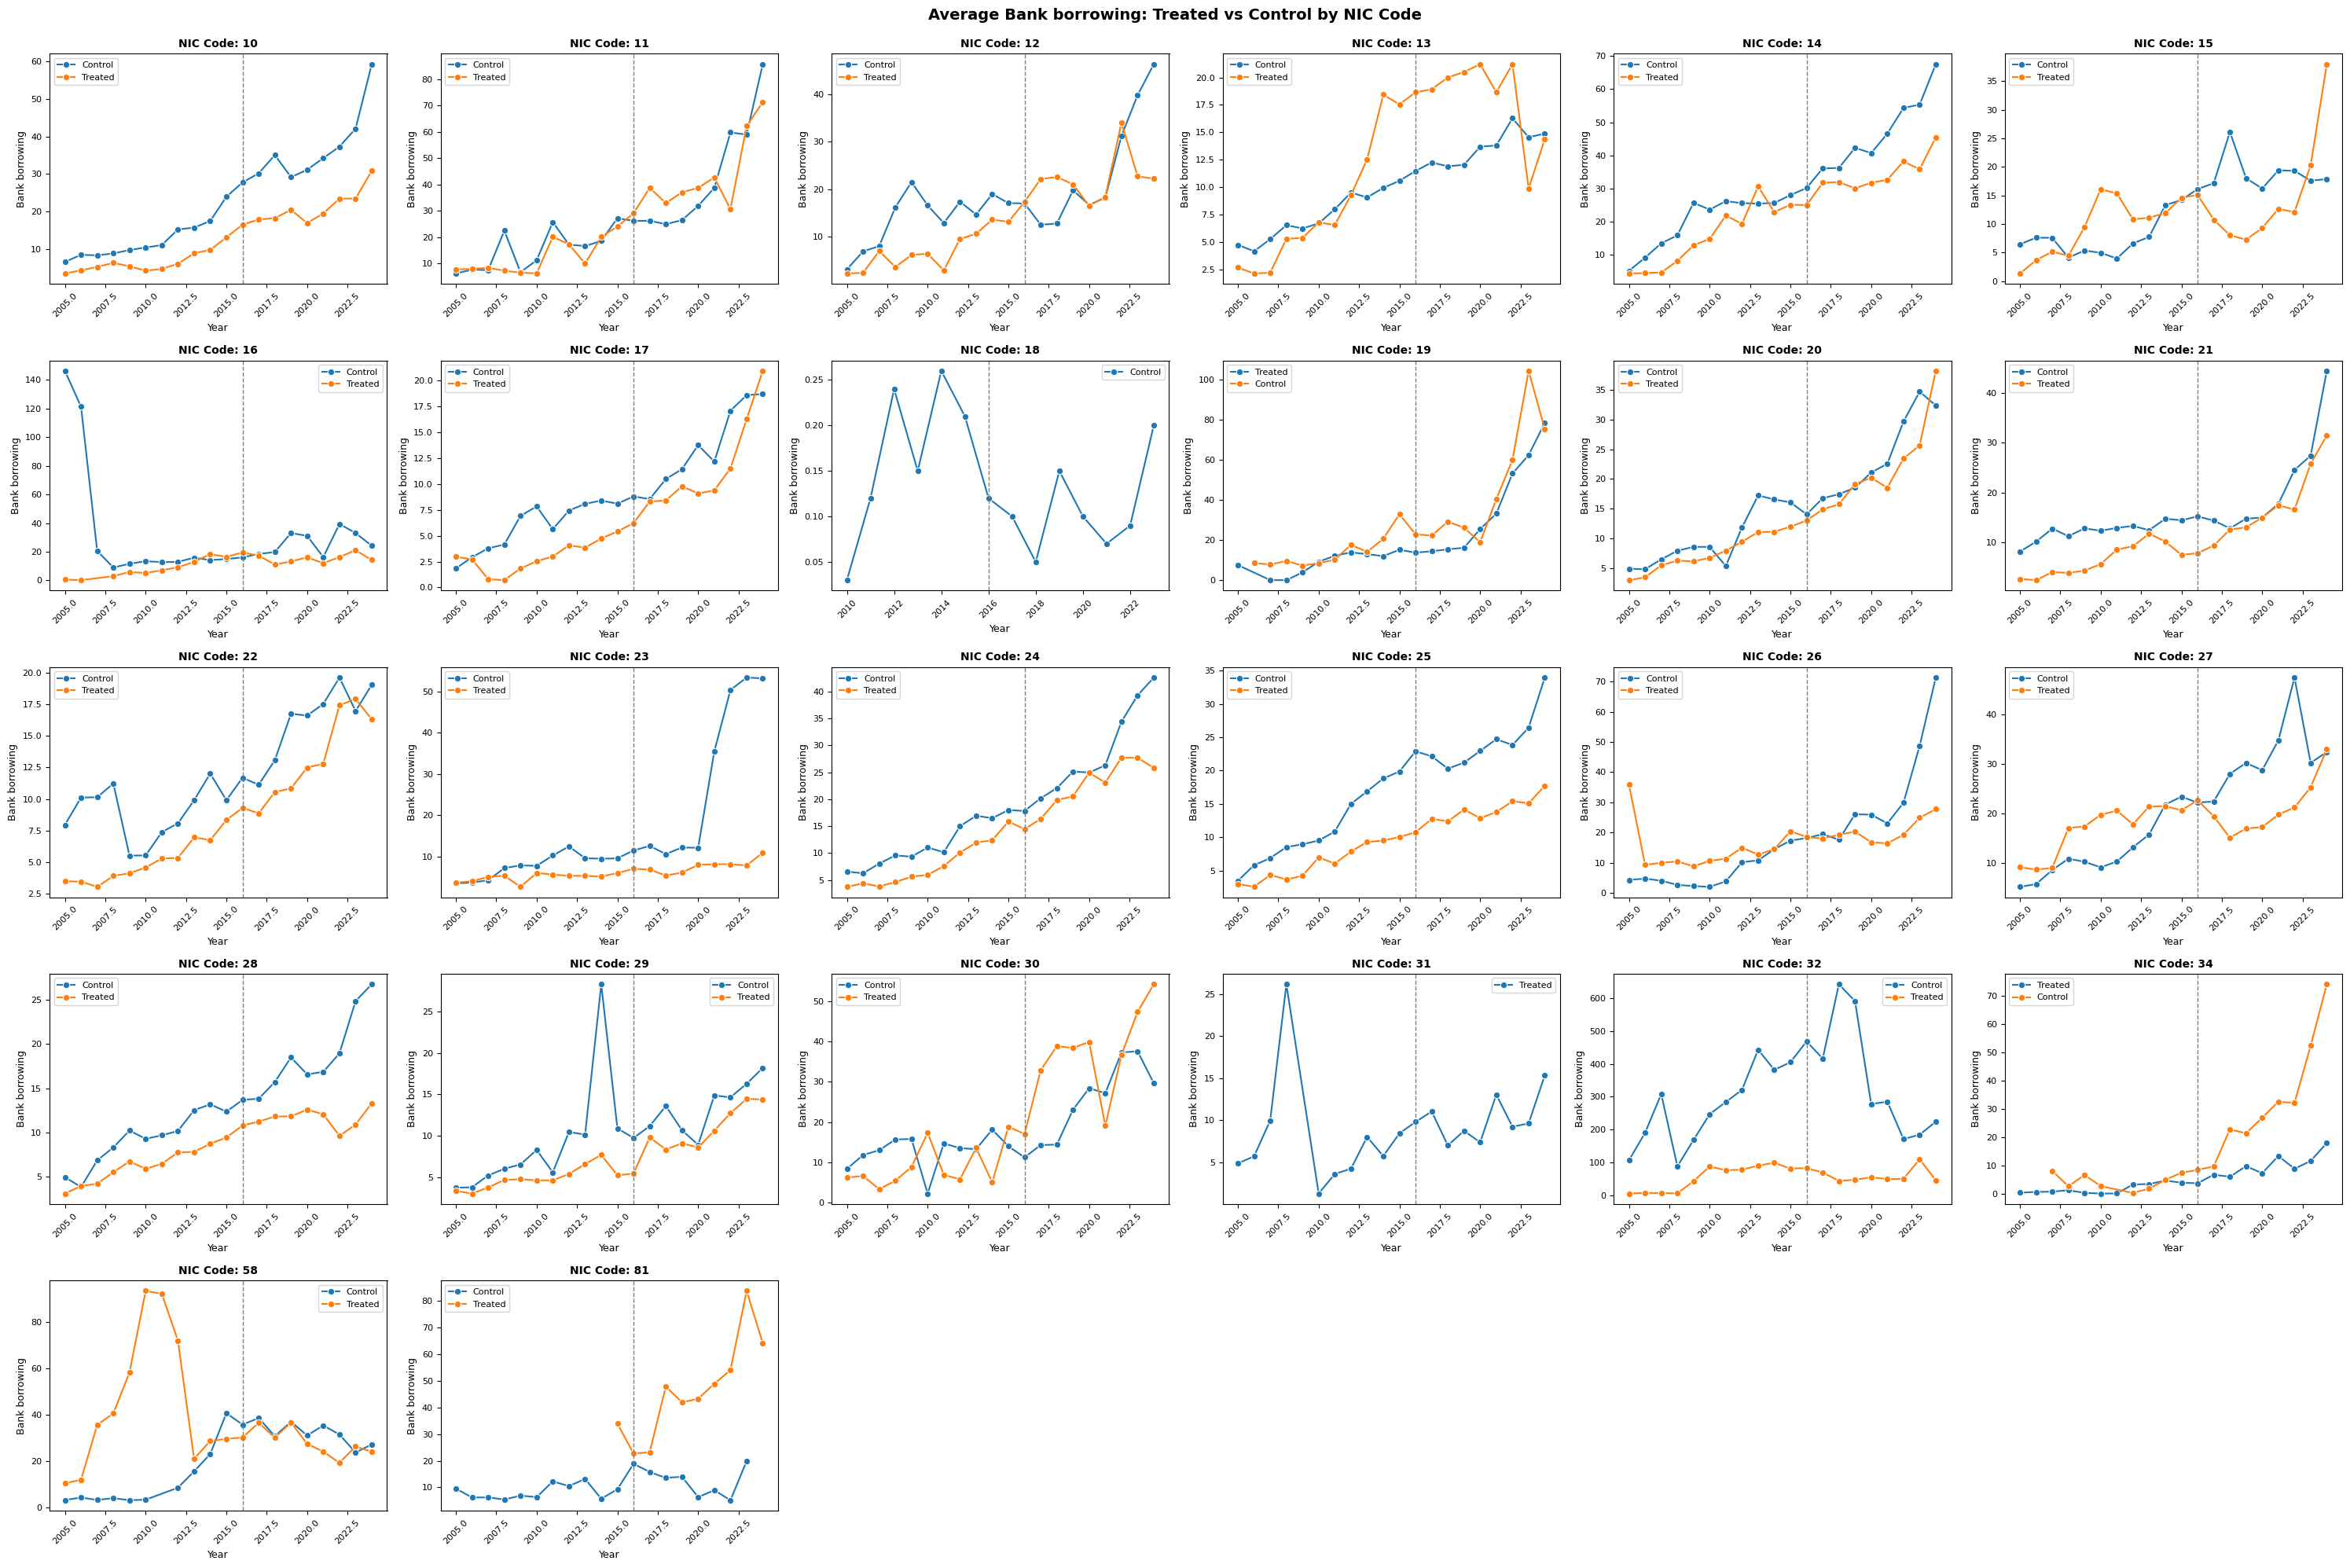

In [72]:
import pandas as pd
import numpy as np

df = pd.read_csv("renamed_master_nic_data.csv")

ID_COL = "Company Name"

df["2D_NIC"] = df["NIC code"].apply(lambda x: int(str(x)[:2]) if len(str(x)) >= 2 else x)

# Merge 2D_NIC back after reshaping
static_cols = df[[ID_COL, "2D_NIC"]].drop_duplicates()

panel = (
    pd.wide_to_long(
        df,
        stubnames=["firm_size", "total_br", "bank_br"],
        i=ID_COL,
        j="year",
        sep="_",
        suffix=r"\d{4}"
    )
    .reset_index()
)


# numeric conversion
num_cols = ["firm_size", "total_br", "bank_br"]
panel[num_cols] = panel[num_cols].apply(pd.to_numeric, errors="coerce")

panel["year"] = panel["year"].astype(int)
panel = panel.sort_values([ID_COL, "year"]).reset_index(drop=True)

# static treatment/control based ONLY on 2015 firm size
size_2015 = (
    panel.loc[panel["year"] == 2015]
         .set_index(ID_COL)["firm_size"]
)

panel["treated_i"] = (
    panel[ID_COL].map(size_2015)
    .between(5, 10, inclusive="left")
    .astype(int)
)

panel["control_i"] = (
    panel[ID_COL].map(size_2015)
    .between(10, 15, inclusive="left")
    .astype(int)
)

# keep only treated + control firms
panel = panel[(panel["treated_i"] == 1) | (panel["control_i"] == 1)].copy()

# DiD time dummies
panel["post"] = (panel["year"] > 2015).astype(int)
panel["did"]  = panel["treated_i"] * panel["post"]

# outcome transform
panel["log_bank_br"] = np.log1p(panel["bank_br"])
panel["log_total_br"] = np.log(panel["total_br"])

# keep rows used in regressions/plots
panel = panel.dropna(subset=["bank_br", "log_bank_br"]).copy()




import seaborn as sns
import matplotlib.pyplot as plt

borrow_choice = input(
    "Choose borrowing type to plot:\n"
    "1 = Bank borrowing\n"
    "2 = Total borrowing\n"
    "Enter 1 or 2: "
).strip()

borrow_map = {"1": "bank_br", "2": "total_br"}
if borrow_choice not in borrow_map:
    raise ValueError("Invalid choice. Enter 1 or 2.")
yvar = borrow_map[borrow_choice]

how = input("Choose aggregation type ('mean' or 'sum'): ").strip().lower()
if how not in ["mean", "sum"]:
    raise ValueError("Invalid input. Enter 'mean' or 'sum'.")

borrow_label_map = {
    "bank_br": "Bank borrowing",
    "total_br": "Total borrowing"
}

# Get unique NIC codes
nic_codes = sorted(panel["2D_NIC"].dropna().unique())
n_nic = len(nic_codes)

# Calculate grid size (roughly square)
n_cols = int(np.ceil(np.sqrt(n_nic)))
n_rows = int(np.ceil(n_nic / n_cols))

# Create subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_nic > 1 else [axes]

for idx, nic in enumerate(nic_codes):
    # Filter data for this NIC code
    nic_data = panel[panel["2D_NIC"] == nic].copy()
    
    # Skip if no data
    if len(nic_data) == 0:
        axes[idx].set_visible(False)
        continue
    
    # Create group labels
    nic_data["group"] = np.where(
        nic_data["treated_i"] == 1, 
        "Treated", 
        "Control"
    )
    
    # Aggregate
    if how == "mean":
        plot_data = nic_data.groupby(["year", "group"], as_index=False)[yvar].mean()
    else:
        plot_data = nic_data.groupby(["year", "group"], as_index=False)[yvar].sum()
    
    # Plot
    ax = axes[idx]
    sns.lineplot(
        data=plot_data, 
        x="year", 
        y=yvar, 
        hue="group", 
        marker="o", 
        errorbar=None,
        ax=ax
    )
    ax.axvline(2016, linestyle="--", color="gray", linewidth=1)
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel(borrow_label_map[yvar], fontsize=9)
    ax.set_title(f"NIC Code: {int(nic)}", fontsize=10, fontweight="bold")
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8, loc='best')

# Hide extra subplots
for idx in range(n_nic, len(axes)):
    axes[idx].set_visible(False)

ylabel = f"Average {borrow_label_map[yvar]}" if how == "mean" else f"Total {borrow_label_map[yvar]}"
fig.suptitle(f"{ylabel}: Treated vs Control by NIC Code", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

In [73]:
# Count unique firms by NIC code and treatment status
firm_counts = panel.groupby(['2D_NIC', 'treated_i'])[ID_COL].nunique().reset_index()
firm_counts.columns = ['2D_NIC', 'treated_i', 'n_firms']

# Pivot to get treated and control in separate columns
firm_counts_pivot = firm_counts.pivot(index='2D_NIC', columns='treated_i', values='n_firms').fillna(0)
firm_counts_pivot.columns = ['Control', 'Treated']
firm_counts_pivot = firm_counts_pivot.astype(int)

# Add total column
firm_counts_pivot['Total'] = firm_counts_pivot['Control'] + firm_counts_pivot['Treated']

# Sort by total firms (descending)
firm_counts_pivot = firm_counts_pivot.sort_values('Total', ascending=False)

print("\n" + "="*60)
print("UNIQUE FIRMS BY NIC CODE AND TREATMENT STATUS")
print("="*60)
print(firm_counts_pivot)
print("="*60)
print(f"Overall Total Firms: {panel[ID_COL].nunique()}")
print(f"Overall Treated Firms: {panel[panel['treated_i']==1][ID_COL].nunique()}")
print(f"Overall Control Firms: {panel[panel['control_i']==1][ID_COL].nunique()}")
print("="*60 + "\n")


UNIQUE FIRMS BY NIC CODE AND TREATMENT STATUS
        Control  Treated  Total
2D_NIC                         
24           80      111    191
10           57      106    163
20           67       93    160
22           52       68    120
13           60       54    114
27           45       69    114
28           39       65    104
21           36       62     98
29           44       48     92
25           35       41     76
26           29       34     63
11           15       36     51
14           24       25     49
17           17       20     37
32           18       17     35
23           17       18     35
15            9       16     25
16            8       11     19
12            3       10     13
34            4        5      9
81            8        1      9
58            2        5      7
19            2        4      6
30            5        1      6
31            0        4      4
18            1        0      1
Overall Total Firms: 1601
Overall Treated Firms: 924
Over

## DiD - TWFE

$  Y_{it} = \beta_{1} * (Treated_i) + \beta_{2} * (Treated_i) + \beta_{3} * (Treated_i × Post_t) + f_i + \lambda_t + e_{it} $  

 where, $Y_{it}$:
- Bank borrowing
- Total borrwing
- Fin instituions bororwing

In [79]:
from linearmodels.panel import PanelOLS

did_start_year = 2005
did_end_year   = 2024


df_did = panel[
    (panel["year"] >= did_start_year) &
    (panel["year"] <= did_end_year)
].copy()

df_did = df_did.set_index([ID_COL, "year"]).sort_index()

mod = PanelOLS(
    df_did["bank_br"],
    df_did[["did"]],
    entity_effects=True,
    time_effects=True
)

res = mod.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:                bank_br   R-squared:                        0.0006
Estimator:                   PanelOLS   R-squared (Between):             -0.0134
No. Observations:               15673   R-squared (Within):              -0.0039
Date:                Sun, Feb 15 2026   R-squared (Overall):             -0.0073
Time:                        10:43:52   Log-likelihood                -9.174e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      8.6805
Entities:                        1273   P-value                           0.0032
Avg Obs:                       12.312   Distribution:                 F(1,14380)
Min Obs:                       1.0000                                           
Max Obs:                       20.000   F-statistic (robust):             4.0231
                            

In [ ]:
#To export the panel data for R analysis 
panel.to_csv("R_panel_data.csv", index=True)\


# Check the pattern Industrywise